In [1]:
# Cài đặt và nạp các thư viện cần thiết cho model
import pandas as pd
import numpy as np
# 2 thu vien tren la doc xu li du lieu va so
import matplotlib.pyplot as plt
#thu vien truc quan hoa
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D, MaxPooling2D, Flatten, Dense, Dropout


!pip install scikeras
from scikeras.wrappers import KerasClassifier

# thu vien danh gia va tien xu li
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

In [2]:
# tai bo fashion show
fashion=tf.keras.datasets.fashion_mnist
(X_train,y_train),(X_test,y_test)=fashion.load_data()
print(f"Kích thước tập huấn luyện: {X_train.shape}") # (50000, 32, 32, 3)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước tập huấn luyện: (60000, 28, 28)


In [ ]:
# xử lí dữ liệu
X_train=X_train.reshape(X_train.shape[0], 28 * 28)
X_test=X_test.reshape(X_test.shape[0], 28 * 28)

minmax_scaler=MinMaxScaler()
X_train=minmax_scaler.fit_transform(X_train)
X_test=minmax_scaler.transform(X_test)

print("number:",len(np.unique(y_train)))
print("class:",np.unique(y_train))

number: 10
class: [0 1 2 3 4 5 6 7 8 9]


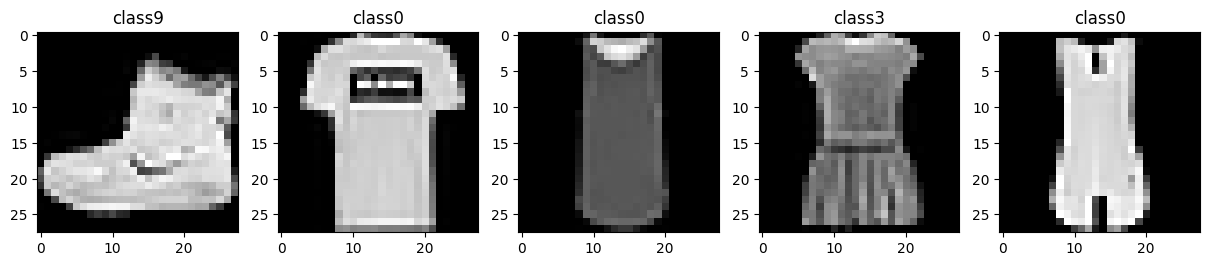

In [ ]:
# trực quan hóa dữ liệu
fig,axes=plt.subplots(1,5,figsize=(15,15))
ax=axes.ravel()

for i in range(5):
    ax[i].imshow(X_train[i].reshape(28,28), cmap='gray')
    ax[i].title.set_text("class"+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [ ]:
#build mô hình ANN
# Khởi tạo mô hình
model = Sequential()

# Thêm lớp ẩn
model.add(Dense(units=256, input_dim=X_train.shape[1], kernel_initializer='uniform', activation='relu'))

# Thêm lớp Dropout để chống overfitting
model.add(Dropout(0.3))

# Thêm lớp đầu ra
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Hiển thị cấu trúc mô hình
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huấn luyện mô hình

model_fit=model.fit(X_train, y_train, epochs=20, verbose=1, validation_data=(X_test, y_test))
# Dự báo thử nghiệm
print(np.argmax(model.predict(X_test)[0]), y_test[0])

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8099 - loss: 0.5322 - val_accuracy: 0.8401 - val_loss: 0.4367
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8554 - loss: 0.4009 - val_accuracy: 0.8397 - val_loss: 0.4323
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8652 - loss: 0.3722 - val_accuracy: 0.8604 - val_loss: 0.3892
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8701 - loss: 0.3490 - val_accuracy: 0.8721 - val_loss: 0.3618
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8757 - loss: 0.3358 - val_accuracy: 0.8723 - val_loss: 0.3557
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8802 - loss: 0.3219 - val_accuracy: 0.8694 - val_loss: 0.3534
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8850 - loss: 0.3135 - val_accuracy: 0.8742 - val_loss: 0.3517
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8877 - loss: 0.3029 - 

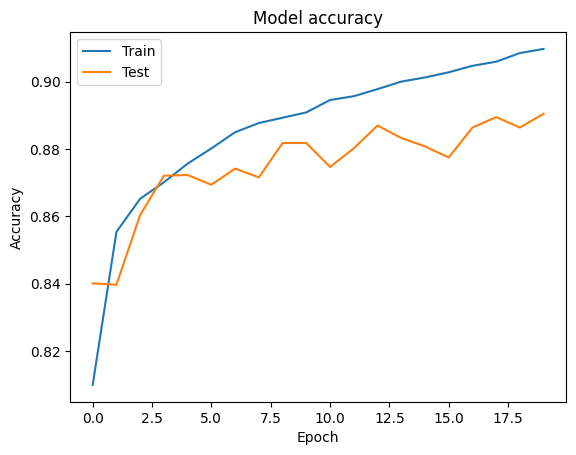

In [ ]:
#các chỉ số biểu đồ đánh giá mô hình
#độ chính xác, số buoc cua tap train tap test
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

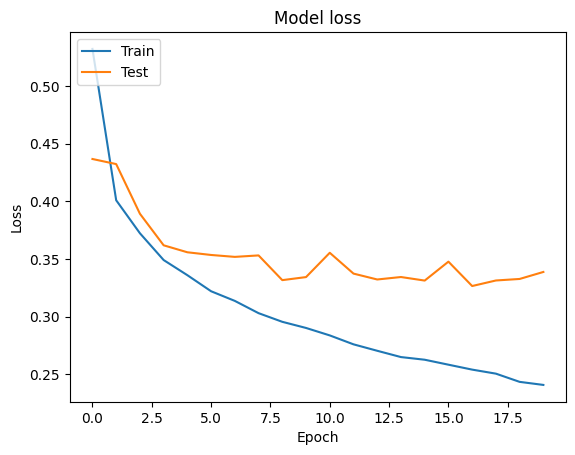

In [ ]:
# danh gia ham mat mat cua model
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


In [ ]:
#dự báo ảnh mới
print(np.argmax(model.predict(X_test)[0]), y_test[0])
print(np.argmax(model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
4 4


In [ ]:
from IPython.display import display, Image, clear_output
from ipywidgets import FileUpload, Output
from PIL import Image as PILImage
import io


class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [ ]:
def preprocess_uploaded_image(image_bytes):

    # đọc ảnh
    img = PILImage.open(io.BytesIO(image_bytes))
    img = img.convert('L')
    img = img.resize((28, 28))
    img_array = np.array(img)
    # đảo màu để giống Fashion MNIST
    img_array = 255 - img_array
    img_array = img_array / 255.0
    img_array = img_array.flatten()

    img_array = img_array.reshape(1, -1)

    return img_array

In [ ]:
uploader = FileUpload(accept='image/*', multiple=False)
output_widget = Output()

def on_upload_change(change):
    with output_widget:
        clear_output()
        if uploader.value:
            uploaded_filename = next(iter(uploader.value))
            uploaded_file_content = uploader.value[uploaded_filename]['content']

            try:

                display(Image(uploaded_file_content, width=100, height=100))


                processed_image = preprocess_uploaded_image(uploaded_file_content)


                prediction = model.predict(processed_image)
                predicted_class_index = np.argmax(prediction)
                predicted_class_name = class_names[predicted_class_index]

                print(f"Predicted Class: {predicted_class_name} (Confidence: {prediction[0][predicted_class_index]:.2f})")

            except Exception as e:
                print(f"Error processing image: {e}")

uploader.observe(on_upload_change, names='value')

display(uploader, output_widget)

FileUpload(value={}, accept='image/*', description='Upload')

Output()

In [ ]:
# doc data tu file csv

mnist_train_path='/content/sample_data/mnist_train_small.csv'
mnist_test_path='/content/sample_data/mnist_test.csv'

mnist_train=pd.read_csv(mnist_train_path)
mnist_test=pd.read_csv(mnist_test_path)

print(mnist_train.shape)
print(mnist_test.shape)


(19999, 785)
(9999, 785)


In [ ]:
# kiem tra thong so lop nhu o tren
X_train=mnist_train.iloc[:,1:]
X_test=mnist_test.iloc[:,1:]
y_train=mnist_train.iloc[:,0]
y_test=mnist_test.iloc[:,0]

print("number:",len(np.unique(y_train)))
print("class:",np.unique(y_train))


number: 10
class: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
# train giống o tren
#thư viện
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D, MaxPooling2D, Flatten, Dense, Dropout


In [ ]:
# train
model_fit=model.fit(X_train, y_train, epochs=30, verbose=1, validation_data=(X_test, y_test))

print(np.argmax(model.predict(X_test)[0]), y_test[0])

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5464 - loss: 39.2715 - val_accuracy: 0.5795 - val_loss: 2.9650
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5016 - loss: 2.6325 - val_accuracy: 0.5834 - val_loss: 2.2632
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5375 - loss: 1.7311 - val_accuracy: 0.6068 - val_loss: 2.0825
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5658 - loss: 1.5500 - val_accuracy: 0.6744 - val_loss: 2.1332
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5970 - loss: 1.3158 - val_accuracy: 0.7048 - val_loss: 1.8300
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6208 - loss: 1.3081 - val_accuracy: 0.7177 - val_loss: 1.6719
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6522 - loss: 1.1541 - val_accuracy: 0.7412 - val_loss: 1.5822
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6660 - loss: 1.1351 - val_accuracy: 0

Saving test.webp to test.webp


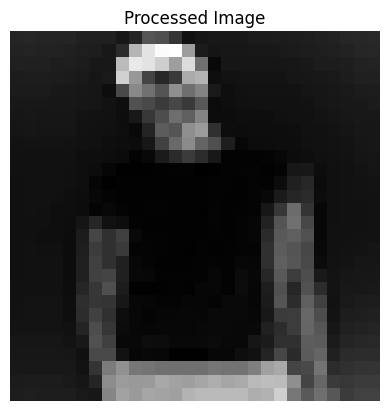

Input shape: (1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted Class Index: 3
Predicted Class Name : Số 3
Confidence: 0.40832373


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

# CLASS NAMES
class_names = [
    "Số 0",
    "Số 1",
    "Số 2",
    "Số 3",
    "Số 4",
    "Số 5",
    "Số 6",
    "Số 7",
    "Số 8",
    "Số 9"
]

# UPLOAD IMAGE
uploaded = files.upload()

# Lấy tên file đầu tiên
file_name = list(uploaded.keys())[0]

# xu li anh dau vao

img_size = (28, 28)

img = Image.open(file_name).convert('L')

# Resize
img = img.resize(img_size)

# Convert sang numpy
img_array = np.array(img)

# Đảo màu nếu nền trắng chữ đen
img_array = 255 - img_array

# Normalize
img_array = img_array / 255.0

# Hiển thị ảnh sau xử lý
plt.imshow(img_array, cmap='gray')
plt.title("Processed Image")
plt.axis('off')
plt.show()

img_input = img_array.reshape(1, 784)

print("Input shape:", img_input.shape)

# =========================
# PREDICT
# =========================
prediction = model.predict(img_input)

predicted_class = np.argmax(prediction)

# Lấy tên class
predicted_name = class_names[predicted_class]

# =========================
# ket qua
# =========================
print("Predicted Class Index:", predicted_class)
print("Predicted Class Name :", predicted_name)
print("Confidence:", np.max(prediction))

In [ ]:
#bài tập

In [ ]:
#bai1
cifar10=tf.keras.datasets.cifar10
(X_train,y_train),(X_test,y_test)=cifar10.load_data()
print(f"Kích thước tập huấn luyện: {X_train.shape}") # (50000, 32, 32, 3)

Kích thước tập huấn luyện: (50000, 32, 32, 3)


In [ ]:
# xử lí dữ liệu
# Reshape X_train and X_test for CIFAR-10 (32x32x3 images)
X_train=X_train.reshape(X_train.shape[0], 32 * 32 * 3)
X_test=X_test.reshape(X_test.shape[0], 32 * 32 * 3)

minmax_scaler=MinMaxScaler()
X_train=minmax_scaler.fit_transform(X_train)
X_test=minmax_scaler.transform(X_test)

print("number:",len(np.unique(y_train)))
print("class:",np.unique(y_train))

number: 10
class: [0 1 2 3 4 5 6 7 8 9]


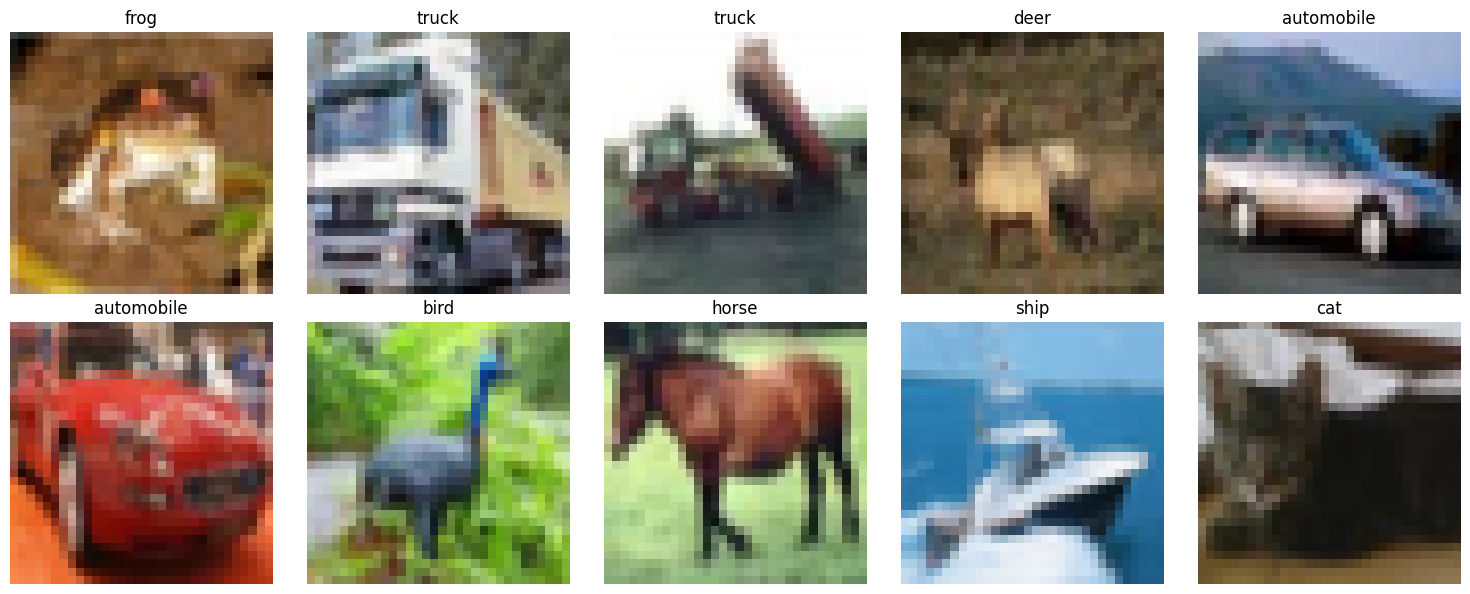

In [ ]:
import matplotlib.pyplot as plt

classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

fig, axes = plt.subplots(2, 5, figsize=(15,6))
ax = axes.ravel()

for i in range(10):
    #
    ax[i].imshow(X_train[i].reshape(32, 32, 3))
    ax[i].set_title(classes[y_train[i][0]])
    ax[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Build mô hình ANN
model = Sequential()

# Input + hidden layer
model.add(Dense(
    units=256,
    input_dim=3072,
    kernel_initializer='uniform',
    activation='relu'
))

# Dropout
model.add(Dropout(0.3))

# Output layer
model.add(Dense(
    units=10,
    kernel_initializer='uniform',
    activation='softmax'
))

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Xem cấu trúc
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,258 (3.01 MB)

 Trainable params: 789,258 (3.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huấn luyện mô hình
model_fit = model.fit(
    X_train,
    y_train,
    epochs=20,
    verbose=1,
    validation_data=(X_test, y_test)
)

# Dự đoán thử
pred = model.predict(X_test)

print("Predict:", np.argmax(pred[0]))
print("Label:", y_test[0][0])

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.2771 - loss: 1.9681 - val_accuracy: 0.3266 - val_loss: 1.8674
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.3213 - loss: 1.8674 - val_accuracy: 0.3746 - val_loss: 1.7430
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3318 - loss: 1.8304 - val_accuracy: 0.3923 - val_loss: 1.7175
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.3436 - loss: 1.8077 - val_accuracy: 0.3898 - val_loss: 1.7061
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.3512 - loss: 1.7895 - val_accuracy: 0.4011 - val_loss: 1.6832
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.3559 - loss: 1.7782 - val_accuracy: 0.4168 - val_loss: 1.6466
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.3608 - loss: 1.7618 - val_accuracy: 0.4200 - val_loss: 1.6536
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.3656 - loss: 1

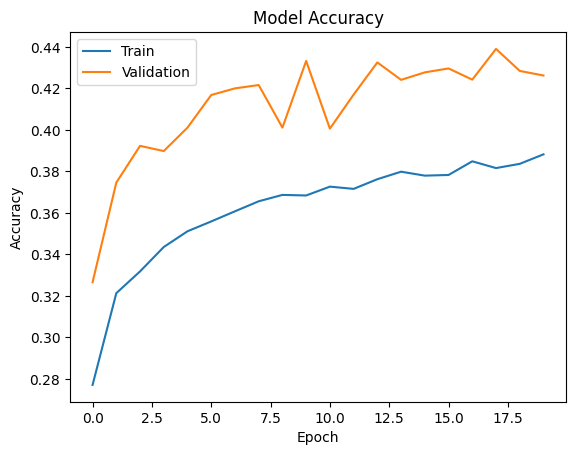

In [ ]:
# Biểu đồ accuracy
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()


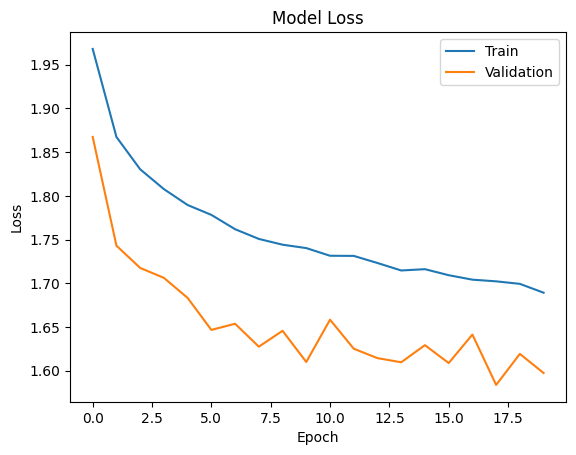

In [ ]:
# Biểu đồ loss
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper right')

plt.show()

In [ ]:

# CLASS CIFAR-10

classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

In [ ]:
import ipywidgets as widgets
from IPython.display import display # Make sure display is imported if not already

# =========================
# TẠO NÚT UPLOAD
# =========================
uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

predict_button = widgets.Button(
    description='Nhận dạng ảnh',
    button_style='success'
)

output_widget = widgets.Output()

display(uploader)
display(predict_button)
display(output_widget)

FileUpload(value={}, accept='image/*', description='Upload')

Button(button_style='success', description='Nhận dạng ảnh', style=ButtonStyle())

Output()

In [ ]:
# =========================
# HIỂN THỊ ẢNH
# =========================
def show_image(img):

    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [ ]:
# =========================
# TIỀN XỬ LÝ ẢNH
# =========================
def preprocess_image(image_bytes):

    # Đọc ảnh
    img = Image.open(io.BytesIO(image_bytes))

    # RGB
    img = img.convert('RGB')

    # Resize
    img = img.resize((32, 32))

    # Hiển thị ảnh
    show_image(img)

    # Convert numpy
    img_array = np.array(img)

    # Normalize
    img_array = img_array / 255.0

    # Flatten cho ANN
    img_array = img_array.reshape(1, 3072)

    return img_array

In [ ]:
# =========================
# DỰ ĐOÁN CLASS
# =========================
def predict_class(processed_image):

    prediction = model.predict(processed_image)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    return predicted_class, confidence

In [ ]:
# =========================
# XỬ LÝ KHI NHẤN NÚT
# =========================
def on_predict_clicked(b):

    with output_widget:

        output_widget.clear_output()

        if len(uploader.value) == 0:
            print("Vui lòng upload ảnh!")
            return

        uploaded_filename = list(uploader.value.keys())[0]

        image_bytes = uploader.value[uploaded_filename]['content']

        processed_image = preprocess_image(image_bytes)

        predicted_class, confidence = predict_class(processed_image)

        print("Kết quả dự đoán:")
        print("Class:", classes[predicted_class])
        print(f"Độ tin cậy: {confidence:.2f}%")
  # =========================
# GÁN SỰ KIỆN CHO BUTTON
# =========================
predict_button.on_click(on_predict_clicked)

In [ ]:
#bài 2:


# doc data tu file csv

mnist_train_path='/content/sample_data/mnist_train.csv'
mnist_test_path='/content/sample_data/mnist_test.csv'

mnist_train=pd.read_csv(mnist_train_path)
mnist_test=pd.read_csv(mnist_test_path)

print(mnist_train.shape)
print(mnist_test.shape)


(60000, 785)
(10000, 785)


In [ ]:
# xử lí dữ liệu

X_train = X_train.reshape(X_train.shape[0], 32 * 32 * 3)
X_test = X_test.reshape(X_test.shape[0], 32 * 32 * 3)

minmax_scaler = MinMaxScaler()

X_train = minmax_scaler.fit_transform(X_train)
X_test = minmax_scaler.transform(X_test)

print("number:", len(np.unique(y_train)))
print("class:", np.unique(y_train))

number: 10
class: [0 1 2 3 4 5 6 7 8 9]


Train shape: (60000, 785)
Test shape : (10000, 785)
Số class: 10
Các class: [0 1 2 3 4 5 6 7 8 9]


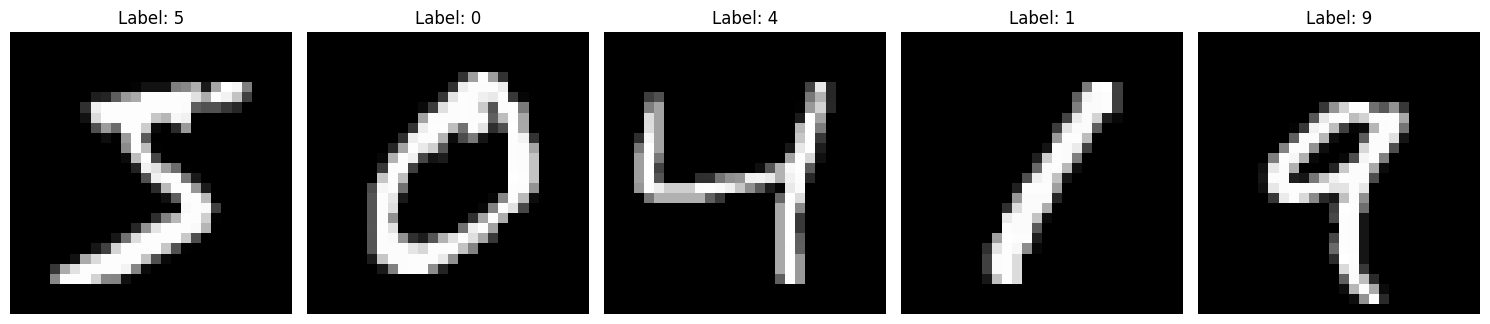

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9286 - loss: 0.2375 - val_accuracy: 0.9613 - val_loss: 0.1238
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9695 - loss: 0.0986 - val_accuracy: 0.9680 - val_loss: 0.1082
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9786 - loss: 0.0671 - val_accuracy: 0.9676 - val_loss: 0.1168
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9831 - loss: 0.0531 - val_accuracy: 0.9743 - val_loss: 0.0908
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9867 - loss: 0.0418 - val_accuracy: 0.9746 - val_loss: 0.0922
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9884 - loss: 0.0346 - val_accuracy: 0.9753 - val_loss: 0.0972
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9897 - loss: 0.0314 - val_accuracy: 0.9755 - val_loss: 0.1044
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9911 - loss: 0.0268 - 

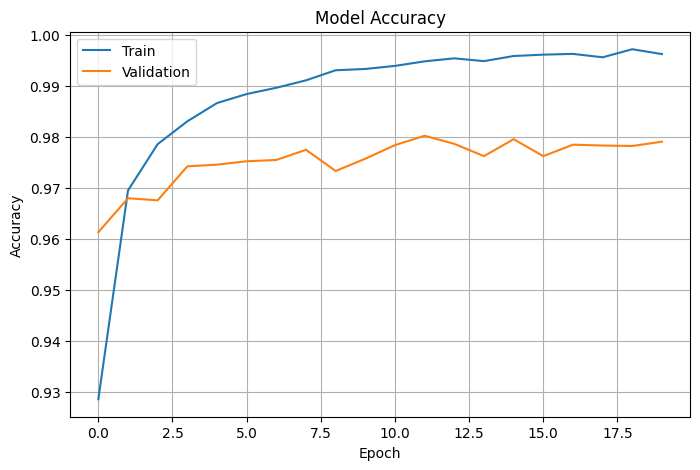

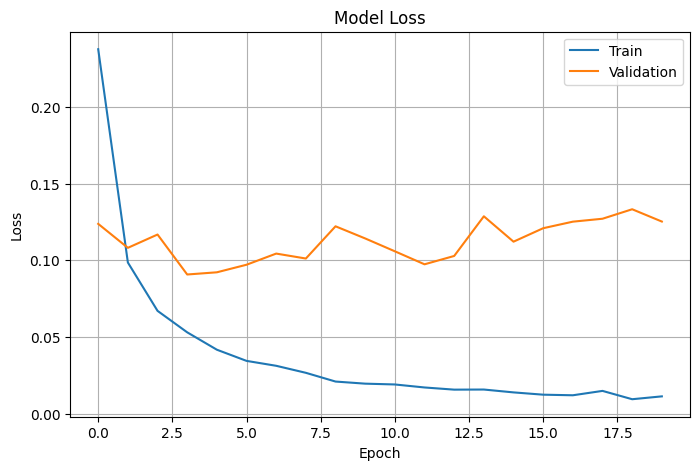

FileUpload(value={}, accept='image/*', description='Upload')

Output()

In [ ]:
# =======================================================
# 1. IMPORT THƯ VIỆN
# =======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

from PIL import Image

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

from ipywidgets import FileUpload, Output
from IPython.display import display, clear_output


# doc

def load_data():

    mnist_train_path = '/content/sample_data/mnist_train.csv'
    mnist_test_path = '/content/sample_data/mnist_test.csv'

    mnist_train = pd.read_csv(mnist_train_path)
    mnist_test = pd.read_csv(mnist_test_path)

    print("Train shape:", mnist_train.shape)
    print("Test shape :", mnist_test.shape)

    return mnist_train, mnist_test


#xu li


def preprocess_data(mnist_train, mnist_test):

    # tách dữ liệu và label
    X_train = mnist_train.iloc[:,1:].values
    y_train = mnist_train.iloc[:,0].values

    X_test = mnist_test.iloc[:,1:].values
    y_test = mnist_test.iloc[:,0].values

    # chuẩn hóa
    minmax_scaler = MinMaxScaler()

    X_train = minmax_scaler.fit_transform(X_train)
    X_test = minmax_scaler.transform(X_test)

    # one hot encoding
    y_train_cat = to_categorical(y_train, 10)
    y_test_cat = to_categorical(y_test, 10)

    print("Số class:", len(np.unique(y_train)))
    print("Các class:", np.unique(y_train))

    return (
        X_train,
        y_train,
        X_test,
        y_test,
        y_train_cat,
        y_test_cat,
        minmax_scaler
    )


#data

def visualize_data(X_train, y_train):

    fig, axes = plt.subplots(1,5, figsize=(15,5))

    for i, ax in enumerate(axes):

        img = X_train[i].reshape(28,28)

        ax.imshow(img, cmap='gray')

        ax.set_title("Label: " + str(y_train[i]))

        ax.axis('off')

    plt.tight_layout()
    plt.show()




def build_ann_model():

    model = Sequential()

    model.add(Dense(
        256,
        activation='relu',
        input_shape=(784,)
    ))

    model.add(Dense(
        128,
        activation='relu'
    ))

    model.add(Dense(
        64,
        activation='relu'
    ))

    model.add(Dense(
        10,
        activation='softmax'
    ))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

#train

def train_model(model, X_train, y_train_cat):

    history = model.fit(
        X_train,
        y_train_cat,
        epochs=20,
        batch_size=32,
        validation_split=0.2
    )

    return history




def evaluate_model(model, X_test, y_test_cat):

    loss, accuracy = model.evaluate(
        X_test,
        y_test_cat
    )

    print("Loss     :", loss)
    print("Accuracy :", accuracy)



#  ACCURACY


def plot_accuracy(history):

    plt.figure(figsize=(8,5))

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])

    plt.title('Model Accuracy')

    plt.ylabel('Accuracy')

    plt.xlabel('Epoch')

    plt.legend(['Train', 'Validation'])

    plt.grid()

    plt.show()


#loss

def plot_loss(history):

    plt.figure(figsize=(8,5))

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])

    plt.title('Model Loss')

    plt.ylabel('Loss')

    plt.xlabel('Epoch')

    plt.legend(['Train', 'Validation'])

    plt.grid()

    plt.show()


#xuli anh

def preprocess_uploaded_image(image_bytes, scaler):

    img = Image.open(io.BytesIO(image_bytes))

    # chuyển grayscale
    img = img.convert('L')

    # resize về 28x28
    img = img.resize((28,28))

    # chuyển numpy
    img_array = np.array(img)

    # đảo màu
    img_array = 255 - img_array

    # threshold làm nét rõ hơn
    img_array = np.where(img_array > 100, 255, 0)

    # hiển thị ảnh sau xử lý
    plt.figure(figsize=(3,3))

    plt.imshow(img_array, cmap='gray')

    plt.title("Processed Image")

    plt.axis('off')

    plt.show()

    # flatten
    img_array = img_array.reshape(1,784)

    # normalize
    img_array = img_array / 255.0

    return img_array


#upload anh

def upload_and_predict(model, scaler):

    uploader = FileUpload(
        accept='image/*',
        multiple=False
    )

    output = Output()

    display(uploader, output)

    def on_upload_change(change):

        with output:

            clear_output()

            if uploader.value:

                uploaded_filename = next(iter(uploader.value))

                image_bytes = uploader.value[
                    uploaded_filename
                ]['content']

                processed_image = preprocess_uploaded_image(
                    image_bytes,
                    scaler
                )

                prediction = model.predict(processed_image)

                predicted_label = np.argmax(prediction)


                print("KẾT QUẢ NHẬN DẠNG:", predicted_label)


                print("\nXác suất từng số:\n")

                for i, prob in enumerate(prediction[0]):

                    print(f"So {i}: {prob:.4f}")

    uploader.observe(
        on_upload_change,
        names='value'
    )


#main

# đọc data
mnist_train, mnist_test = load_data()

# tiền xử lý
(
    X_train,
    y_train,
    X_test,
    y_test,
    y_train_cat,
    y_test_cat,
    minmax_scaler
) = preprocess_data(
    mnist_train,
    mnist_test
)

# trực quan hóa dữ liệu
visualize_data(X_train, y_train)

# tạo model
model = build_ann_model()

# train model
history = train_model(
    model,
    X_train,
    y_train_cat
)

# đánh giá
evaluate_model(
    model,
    X_test,
    y_test_cat
)

# biểu đồ accuracy
plot_accuracy(history)

# biểu đồ loss
plot_loss(history)

# upload ảnh để dự đoán
upload_and_predict(
    model,
    minmax_scaler
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.39GR5K_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Classes: ['cat', 'dog']
Train: 16283
Validation: 3490
Test: 3489


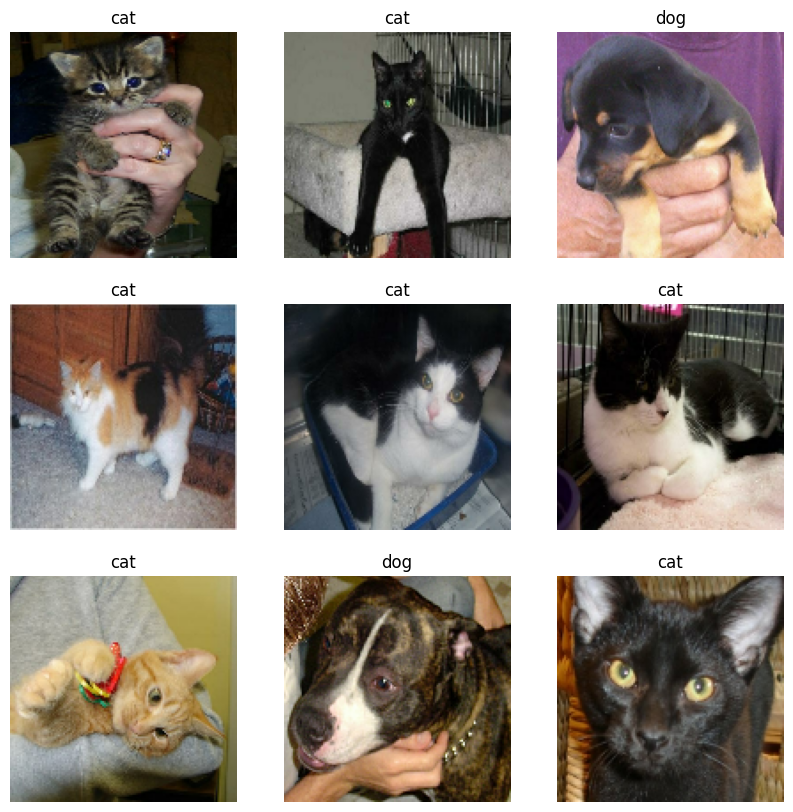

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 341s 665ms/step - accuracy: 0.6705 - loss: 0.5961 - val_accuracy: 0.7461 - val_loss: 0.5159
Epoch 2/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 371s 642ms/step - accuracy: 0.7625 - loss: 0.4914 - val_accuracy: 0.7791 - val_loss: 0.4745
Epoch 3/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 389s 657ms/step - accuracy: 0.8064 - loss: 0.4153 - val_accuracy: 0.7716 - val_loss: 0.4614
Epoch 4/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 346s 678ms/step - accuracy: 0.8457 - loss: 0.3525 - val_accuracy: 0.8155 - val_loss: 0.4275
Epoch 5/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 339s 665ms/step - accuracy: 0.8730 - loss: 0.2910 - val_accuracy: 0.8238 - val_loss: 0.4289
Epoch 6/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 362s 710ms/step - accuracy: 0.9062 - loss: 0.2231 - val_accuracy: 0.8186 - val_loss: 0.4866
Epoch 7/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 348s 682ms/step - accuracy: 0.9355 - loss: 0.1629 - val_accuracy: 0.8115 - val_loss: 0.5796
Epoch 8/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 375s 668ms/step - accuracy: 0.9555 -

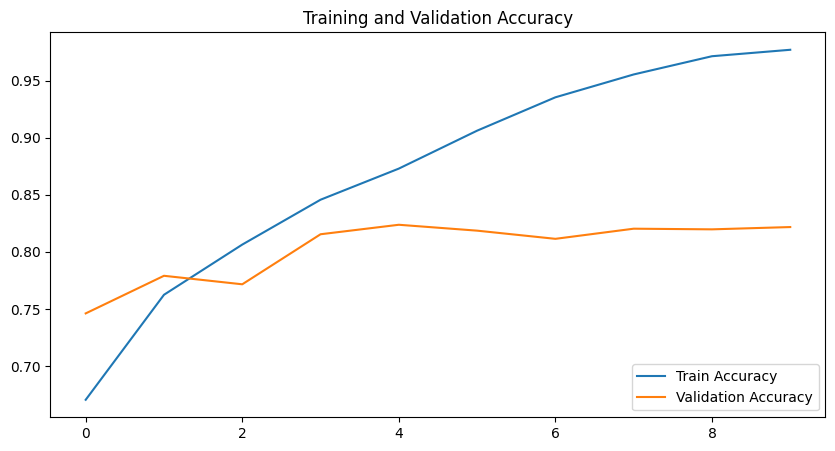

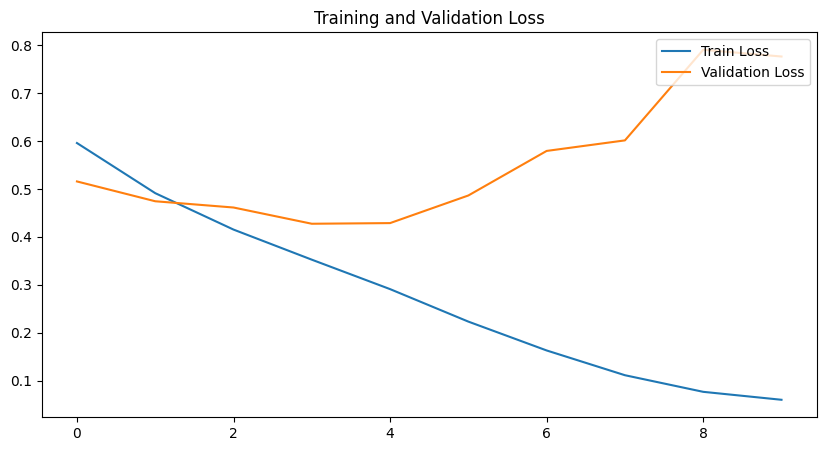

Đã lưu model!


Saving meo.webp to meo.webp
Đã upload: meo.webp


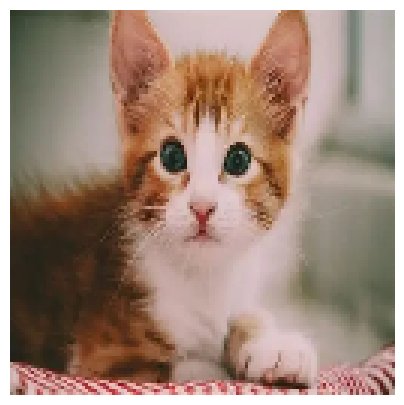

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Prediction : CAT
Confidence : 0.9776893258094788


In [ ]:
# bải
# 1. IMPORT THƯ VIỆN


import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Rescaling

from google.colab import files
from IPython.display import display
from PIL import Image

#tai data

(train_ds, val_ds, test_ds), ds_info = tfds.load(
    'cats_vs_dogs',
    split=[
        'train[:70%]',
        'train[70%:85%]',
        'train[85%:]'
    ],
    as_supervised=True,
    with_info=True
)

#tomtat data

class_names = ds_info.features['label'].names

print("Classes:", class_names)

print("Train:", len(train_ds))
print("Validation:", len(val_ds))
print("Test:", len(test_ds))

#tien xu ly du lieu

IMG_SIZE = 128

def preprocess(image, label):

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = tf.cast(image, tf.float32)

    return image, label

train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)
test_ds = test_ds.map(preprocess)



BATCH_SIZE = 32

train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE)

val_ds = val_ds.batch(BATCH_SIZE)

test_ds = test_ds.batch(BATCH_SIZE)



AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

test_ds = test_ds.prefetch(AUTOTUNE)

#anhload

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()


# 8. TẠO MODEL CNN


model = Sequential([

    Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(1, activation='sigmoid')
])



model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


# TRAIN MODEL


EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

#danhgia

test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)


# 12. BIỂU ĐỒ ACCURACY


acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(EPOCHS)

plt.figure(figsize=(10,5))

plt.plot(epochs_range, acc, label='Train Accuracy')

plt.plot(epochs_range, val_acc, label='Validation Accuracy')

plt.legend(loc='lower right')

plt.title('Training and Validation Accuracy')

plt.show()


# 13. BIỂU ĐỒ LOSS

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10,5))

plt.plot(epochs_range, loss, label='Train Loss')

plt.plot(epochs_range, val_loss, label='Validation Loss')

plt.legend(loc='upper right')

plt.title('Training and Validation Loss')

plt.show()


# 14. LƯU MODEL


model.save("cats_vs_dogs_model.h5")

print("Đã lưu model!")


# 15. HÀM DỰ ĐOÁN ẢNH


def predict_image(image_path):

    img = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    img_array = tf.keras.utils.img_to_array(img)

    img_array = tf.expand_dims(img_array, 0)

    prediction = model.predict(img_array)

    score = prediction[0][0]

    if score > 0.5:

        print("======================")
        print("Prediction : DOG")
        print("Confidence :", float(score))
        print("======================")

    else:

        print("======================")
        print("Prediction : CAT")
        print("Confidence :", float(1-score))
        print("======================")


# 16. NÚT LOAD ẢNH ĐỂ PHÂN LOẠI


def upload_and_predict():

    uploaded = files.upload()

    for filename in uploaded.keys():

        print("Đã upload:", filename)

        predict_image(filename)


# 17. CHẠY LOAD ẢNH


upload_and_predict()